<a href="https://colab.research.google.com/github/mtlkmoses-hue/Energy-Consumption-Prediction/blob/main/Kgomotso_Computer_Vision_Beginner_Kaggle_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Computer Vision for Beginners
## Live Coding Notebook using the Kaggle Digit Recognizer Dataset

This notebook gives a **gentle introduction to computer vision** and then walks step by step through a small image classification task.

We will use the **Kaggle Digit Recognizer** dataset, which is based on the famous **MNIST handwritten digits** data. Kaggle describes this competition as a way to learn computer vision fundamentals with handwritten digit images. citeturn660158search2turn660158search5

---

## Learning goals

By the end of this notebook, students should be able to:

- explain what computer vision is
- understand that images are stored as numbers
- inspect image data in tabular form
- visualize handwritten digit images
- prepare image data for machine learning
- train a simple model to classify digits
- test the model on unseen data
- appreciate how computer vision works in practice

## Short Notes: What is Computer Vision?

**Computer Vision** is a field of artificial intelligence that helps computers understand and interpret images.

A human being looks at a picture and may immediately recognize a face, a car, a cat, or a handwritten number. A computer does not see an image in the same way. It sees an image as a grid of **pixels**, and each pixel is represented by a number.

### Key terms

**Image**  
A digital picture stored on a computer.

**Pixel**  
The smallest unit of an image. An image is made up of many pixels.

**Grayscale image**  
An image made of shades of black, white, and gray.

**RGB image**  
A color image made from three color channels: Red, Green, and Blue.

**Label**  
The correct answer assigned to an image.  
Example: an image of a handwritten 7 has the label **7**.

**Feature**  
A measurable input used by a model. In image classification, pixel values act as features.

**Image classification**  
The task of teaching a computer to assign a category or label to an image.

### Why computer vision matters

Computer vision is used in many real-world systems, including:

- facial recognition
- medical image analysis
- self-driving cars
- quality inspection in factories
- document scanning
- handwriting recognition

### Why we are starting with digits

For beginners, handwritten digits are an excellent place to start because:

- the images are small and simple
- the classes are easy to understand
- students can see clearly how images become data
- the task connects images with machine learning in a direct way

### Important idea

Today, we are **not** trying to master deep learning or advanced computer vision.

We are trying to understand a foundational idea:

> A computer can learn patterns from image pixels and use those patterns to make predictions.

## About the dataset

We are using the **Kaggle Digit Recognizer** dataset.

It contains many handwritten digits from **0 to 9**. Each row represents one image, and the columns contain pixel values. Kaggle presents it as a beginner-friendly computer vision task based on the famous MNIST data. citeturn660158search2turn660158search5

### Dataset structure

- `label` = the digit the image represents
- `pixel0` to `pixel783` = the pixel values for a 28 × 28 image
- each image has **784 pixels total**
- pixel values usually range from **0 to 255**

### Before you run this notebook

Download the dataset from Kaggle and place the `train.csv` file in the **same folder** as this notebook.

This notebook expects:

```text
train.csv
```

In [1]:
# Step 1: Import the libraries we need

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
!unzip train.csv.zip
!unzip test.csv.zip

import pandas as pd

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

Archive:  train.csv.zip
  inflating: train.csv               
Archive:  test.csv.zip
  inflating: test.csv                


## Step 2: Load the dataset

We will read the Kaggle `train.csv` file into pandas.

If you get a file error, make sure the CSV file is in the same folder as this notebook.

In [ ]:
!unzip train.csv.zip
!unzip test.csv.zip

Archive:  train.csv.zip
  inflating: train.csv               
Archive:  test.csv.zip
  inflating: test.csv                


In [3]:
# Step 2: Load the Kaggle dataset

df = pd.read_csv("train.csv")
print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Use the 'Copy path' strings here
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

# Separate the 'label' from the pixel data in the training set
y = train['label']
X = train.drop(columns=['label'])

print("Files loaded successfully!")
print(f"Training images: {X.shape[0]}")
print(f"Test images (to predict later): {test.shape[0]}")

Files loaded successfully!
Training images: 42000
Test images (to predict later): 28000


## 📥 Step 2: Loading and Inspecting the Dataset

In this step, we load the dataset and take a first look at its structure.

### 🔹 Code Explanation

`df = pd.read_csv("train.csv")`
This line loads the dataset from the file **train.csv** into a pandas DataFrame called `df`.
A DataFrame is like a table (similar to Excel), where:

* each **row** represents an observation (an image)
* each **column** represents a feature (pixel values)

---

`print("Dataset loaded successfully.")`
This line prints a confirmation message to show that the dataset has been loaded without errors.

---

`print("Shape:", df.shape)`
This displays the **dimensions of the dataset**.
The output `(42000, 785)` means:

* **42000 rows** → 42,000 images
* **785 columns** → 1 label column + 784 pixel columns

---

`df.head()`
This displays the **first 5 rows** of the dataset so we can inspect what the data looks like.

---

## 🔍 Understanding the Output

After running the code, we see a table with columns such as:

`label, pixel0, pixel1, pixel2, ..., pixel783`

---

### 🔹 What each row represents

Each row represents **one image of a handwritten digit**.

---

### 🔹 What each column represents

**label column**

* This is the **correct answer** for the image
* Example:

  * `1` → the image is a digit 1
  * `4` → the image is a digit 4

**pixel0 to pixel783**

* These are the **pixel values of the image**
* Each value represents the light intensity at a specific position in the image

---

### 🔹 What the pixel values mean

Pixel values range from **0 to 255**:

* `0` → black (no light)
* `255` → white (maximum light)
* values in between → shades of gray

---

## 🧠 How to Think About This Table

Instead of thinking of this as just numbers, think of it like this:

Each row is actually a **flattened image**.

* The original image size is **28 × 28 pixels**
* That gives **784 pixels total**
* These 784 pixel values are stored in a single row

---

## 🔄 Why the Data Looks Like This

The image has been flattened into a row:

`[ pixel0, pixel1, pixel2, ..., pixel783 ]`

Later, we will convert this back into a 2D image using:

`image = pixels.reshape(28, 28)`

---

## 💡 Key Insight

At this stage, the computer does not see a picture.
It only sees rows of numbers representing light intensity.

---

## 🎯 What We Have Achieved

By the end of this step, we have:

* successfully loaded the dataset
* understood its size and structure
* identified that each row represents an image
* learned that pixel values are the features the model will use

---


## Step 3: Understand the dataset

Let us inspect:

- the first few rows
- the column names
- whether there are missing values
- how many examples we have for each digit

In [5]:
# Step 3a: Basic information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [11]:
# Inspect the first few rows
print("--- First 5 Rows ---")
display(df.head())

# Inspect the column names (Pixel 0 to 783)
print("\n--- Column Names (First 10 and Last 5) ---")
print(df.columns[:10].tolist(), "...", df.columns[-5:].tolist())


# Check the balance of digits (Target Distribution)
print("\n--- Count of Each Digit (0-9) ---")
print(df['label'].value_counts().sort_index())

--- First 5 Rows ---


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



--- Column Names (First 10 and Last 5) ---
['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7', 'pixel8'] ... ['pixel779', 'pixel780', 'pixel781', 'pixel782', 'pixel783']

--- Count of Each Digit (0-9) ---
label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


In [13]:
# Step 3b: Check for missing values

# This counts how many 'NaN' or empty cells exist in the entire table
missing_values = df.isnull().sum().sum()
print(f"\n--- Missing Values: {missing_values} ---")


--- Missing Values: 0 ---


In [8]:
# Step 3c: Count how many examples there are for each label

label_counts = df["label"].value_counts().sort_index()
label_counts

,count
label,
0,4132
1,4684
2,4177
3,4351
4,4072
5,3795
6,4137
7,4401
8,4063


## 🔢 Step 3c: Counting the Number of Examples per Label

In this step, we count how many images we have for each digit (0 to 9).

---

### 🔹 Code Explanation

`label_counts = df["label"].value_counts().sort_index()`

This line performs three important operations:

* `df["label"]`
  Selects the **label column**, which contains the correct digit (0–9) for each image.

* `.value_counts()`
  Counts how many times each digit appears in the dataset.

* `.sort_index()`
  Sorts the results in order from **0 to 9**, so it is easier to read.

---

`label_counts`

This displays the result as a table.

---

## 🔍 Understanding the Output

The output looks like this:

```
label   count
0       4132
1       4684
2       4177
3       4351
4       4072
5       3795
6       4137
7       4401
8       4063
9       ...
```

---

### 🔹 What this means

* Each number (0–9) represents a **digit class**
* The count shows **how many images we have for that digit**

For example:

* `0 → 4132` means there are **4,132 images of the digit 0**
* `1 → 4684` means there are **4,684 images of the digit 1**

---

## 🧠 How to Think About This

You can think of this as checking:

> “Do we have a balanced dataset?”

In other words:

* Do we have roughly the same number of examples for each digit?
* Or are some digits overrepresented or underrepresented?

---

## ⚖️ Why This Step Matters

This step helps us understand the **distribution of our data**.

* If one digit appears much more than others, the model might become biased
* A balanced dataset helps the model learn all classes fairly

In this case:

* The numbers are **fairly evenly distributed**
* This is good for training a machine learning model

---

## 💡 Key Insight

> Before training any model, it is important to understand how your data is distributed.

---

## 🎯 What We Have Learned

By the end of this step, we:

* counted how many examples exist for each digit
* confirmed that the dataset is reasonably balanced
* prepared ourselves to train a fair and reliable model

---


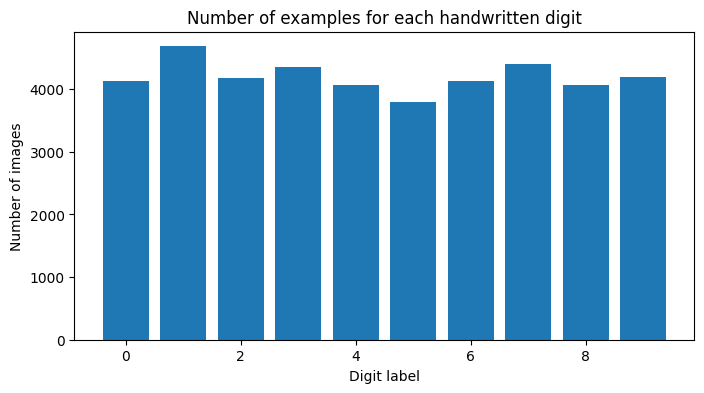

In [14]:
# Step 3d: Visualize label distribution

plt.figure(figsize=(8, 4))
plt.bar(label_counts.index, label_counts.values)
plt.xlabel("Digit label")
plt.ylabel("Number of images")
plt.title("Number of examples for each handwritten digit")
plt.show()

## Step 4: Separate features and labels

In machine learning:

- **X** = input features
- **y** = target labels

Here:

- `y` is the digit label
- `X` is all the pixel columns

In [15]:
# Step 4: Split into features and labels

X = df.drop("label", axis=1)
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (42000, 784)
y shape: (42000,)




## 🎯 Step 4: Splitting Data into Features (X) and Labels (y)

In this step, we separate our dataset into:

* **input features (X)** → what the model uses to learn
* **labels (y)** → the correct answers the model should predict

This is a fundamental concept in machine learning.

---

## 🔹 Code Explanation

`X = df.drop("label", axis=1)`
This removes the **label column** from the dataset.
The remaining columns (`pixel0` to `pixel783`) become the **features (X)**.
These represent the pixel values of each image.

---

`y = df["label"]`
This selects the **label column**, which contains the correct digit (0–9).
This becomes the **target variable (y)**.

---

`print("X shape:", X.shape)`
Displays the shape of the feature matrix.

Output:

* `(42000, 784)`

  * 42,000 rows → 42,000 images
  * 784 columns → 784 pixel values per image

---

`print("y shape:", y.shape)`
Displays the shape of the labels.

Output:

* `(42000,)`

  * 42,000 labels → one label per image

---

## 🔍 Understanding the Output

* **X (features)**

  * Each row represents one image
  * Each column represents a pixel
  * So each image is described by **784 numerical values**

* **y (labels)**

  * Each value represents the correct digit (0–9)
  * There is one label for each image

---

## 🧠 Connecting to Machine Learning Concepts

This step reflects a core idea in machine learning:

> We train a model by giving it inputs (features) and the correct outputs (labels).

---

### 🔹 In this dataset

**Input (X):**

* Pixel values of the image
* Example:
  `[0, 0, 0, ..., 255, 120, ...]`
* This is what the model *sees*

---

**Output (y):**

* The digit label
* Example:
  `7`
* This is what the model must learn to predict

---

## 🧩 Simple Analogy

Think of teaching a child:

* You show them an image of a handwritten number
* You tell them: “This is a 5”

Over time:

* They learn patterns in the image
* They can recognize new numbers

In this analogy:

* **Image (pixels)** → input features (X)
* **Correct answer (digit)** → label (y)

---

## 🔄 What the Model Learns

The model learns a relationship between inputs and outputs:

`f(X) → y`

Meaning:

> Given pixel values (X), predict the correct digit (y)

---

## 💡 Key Insight

At this stage, the computer does not see images.
It only sees numerical features (pixel values) and learns patterns that map them to labels.

---

## 🎯 Why This Step Matters

* Machine learning models require:

  * **inputs (X)**
  * **targets (y)**
* Without labels, the model cannot learn (in supervised learning)
* This step prepares the data for training and evaluation

---

## 🚀 What We Have Achieved

By the end of this step, we:

* separated the dataset into inputs and outputs
* defined what the model learns from (X)
* defined what the model predicts (y)
* structured the data correctly for machine learning

---


## Step 5: Visualize some handwritten digits

Even though the data is stored in a table, each row actually represents an image.

Because the image is 28 × 28 pixels, we can reshape 784 pixel values into a 28 × 28 grid and display it.

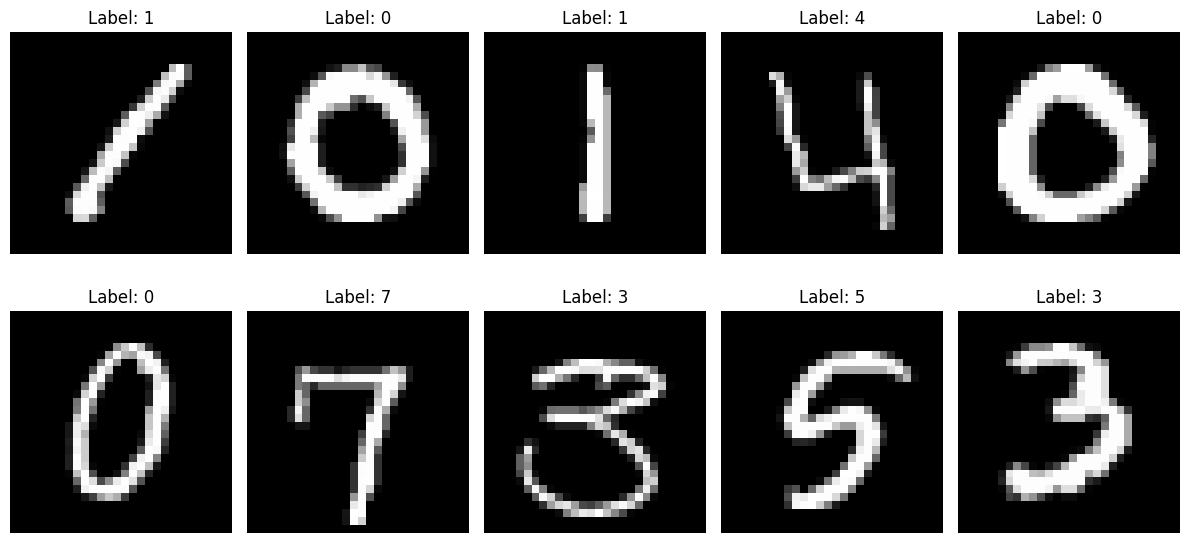

In [ ]:
# Step 5: Show a few handwritten digit images

plt.figure(figsize=(12, 6))

for i in range(10):
    image = X.iloc[i].values.reshape(28, 28)
    label = y.iloc[i]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Normalize the features (X) by dividing by the maximum pixel value
X = X / 255.0

# Verify the change
print(f"New Maximum Pixel Value: {X.max().max()}")
print(f"New Minimum Pixel Value: {X.min().min()}")

New Maximum Pixel Value: 1.0
New Minimum Pixel Value: 0.0



## 🖼️ Step 5: Visualizing Images from the Dataset

In this step, we convert the pixel values back into images so we can see what the data actually looks like.

Up to this point, the computer has only been working with numbers. Now, we transform those numbers into visual images.

---

## 🔹 Code Explanation

`plt.figure(figsize=(12, 6))`

* Creates a blank figure (canvas) for plotting images
* `figsize=(12, 6)` controls the width and height of the display

---

`for i in range(10):`

* Loops through the first **10 images** in the dataset
* This allows us to display multiple images at once

---

`image = X.iloc[i].values.reshape(28, 28)`

* Selects the pixel values for the i-th image
* Converts them into a NumPy array
* Reshapes the 784 values into a **28 × 28 grid**
* This reconstructs the original image

---

`label = y.iloc[i]`

* Retrieves the correct label (digit) for that image
* This is the true answer associated with the image

---

`plt.subplot(2, 5, i + 1)`

* Creates a grid layout of **2 rows and 5 columns**
* Each image is placed in a different position in the grid

---

`plt.imshow(image, cmap="gray")`

* Displays the image
* `cmap="gray"` ensures it is shown in grayscale

---

`plt.title(f"Label: {label}")`

* Adds a title above each image
* Shows the correct digit for that image

---

`plt.axis("off")`

* Removes axis lines and numbers
* Makes the image cleaner and easier to view

---

`plt.tight_layout()`

* Adjusts spacing between images so they don’t overlap

---

`plt.show()`

* Displays all the images on the screen

---

## 🔍 What We Are Trying to Achieve

In previous steps:

* We saw the data as rows of numbers
* Each row had 784 pixel values

In this step, we:

* Convert those numbers back into images
* Visually confirm what each row actually represents

---

## 🧠 Understanding the Output

The output shows:

* 10 images of handwritten digits
* Each image is labeled with its correct digit

For example:

* An image that looks like a “1” is labeled **Label: 1**
* An image that looks like a “4” is labeled **Label: 4**

---

## 🧩 Key Concept Reinforced

> Each row of numbers in the dataset is actually an image.

* The 784 pixel values form a **28 × 28 grid**
* When reshaped, they become a visible digit

---

## 💡 Why This Step Matters

This step helps us:

* verify that our data is correct
* understand how images are represented numerically
* connect abstract numbers to real visual patterns

It also builds intuition for how machine learning models learn from image data.

---

## 🎯 Key Insight

Before this step:

* The data looked like numbers

After this step:

* We see that those numbers represent meaningful images

---

## 🚀 What We Have Achieved

By the end of this step, we:

* transformed numerical data into visual images
* confirmed the relationship between pixels and images
* connected features (X) to labels (y) in a visual way
* made the dataset easier to understand and interpret

---



## Step 6: Look at one image as numbers

This helps students understand that a computer stores images as numbers.

In [17]:
# Step 6: Inspect one image as pixel values

sample_image = X.iloc[0].values.reshape(28, 28)
sample_label = y.iloc[0]

print("Label:", sample_label)
print(sample_image)

Label: 1
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.      

## 🔢 Step 6: Looking at One Image as Numbers

In this step, we inspect a single image in its raw numerical form.

This helps us understand how a computer actually stores and processes images.

---

## 🔹 Code Explanation

`sample_image = X.iloc[0].values.reshape(28, 28)`

* Selects the **first image** from the dataset
* Converts it into a NumPy array
* Reshapes it into a **28 × 28 grid**
* Each value in the grid represents a **pixel intensity**

---

`sample_label = y.iloc[0]`

* Retrieves the **label (correct digit)** for this image
* This is the true answer associated with the image

---

`print("Label:", sample_label)`

* Prints the correct digit for the image

---

`print(sample_image)`

* Displays the image as a **matrix of numbers**
* Each number represents a pixel value

---

## 🔍 Understanding the Output

The output shows two things:

### 1. The Label

Example:
`Label: 1`

This tells us:

* The image represents the digit **1**

---

### 2. The Pixel Matrix

You will see a 28 × 28 grid of numbers like:

```
[[  0   0   0 ...]
 [  0   0   0 ...]
 [  0   0 255 ...]
 ...
]
```

---

## 🧠 What These Numbers Mean

Each number represents the **intensity of light** at a specific pixel:

* `0` → black (no light)
* `255` → white (maximum light)
* values in between → shades of gray

---

## 🧩 Connecting This to Images

What you are seeing is:

> The same image we visualized earlier, but now represented as raw data.

* Each row in the matrix = one row of pixels
* Each column = one column of pixels
* Together, they form the full image

---

## 🔄 Key Concept Reinforced

> A computer does not store images as pictures.
> It stores them as numerical grids.

---

## 🧠 Input vs Output (Machine Learning Perspective)

* **Input (X)**

  * The pixel values (this matrix of numbers)
  * This is what the model uses to learn

* **Output (y)**

  * The label (e.g., 1)
  * This is what the model is trying to predict

---

## 💡 Why This Step Matters

This step helps students:

* understand the connection between **images and data**
* see exactly what the model “sees”
* build intuition for how machine learning works with images

---

## 🎯 Key Insight

> What looks like a simple handwritten digit to us is, to a computer, just a structured grid of numbers.

---

## 🚀 What We Have Achieved

By the end of this step, we:

* inspected one image in numerical form
* understood how pixel values represent images
* connected visual data to machine learning inputs
* reinforced the idea that models learn from numbers, not pictures

---



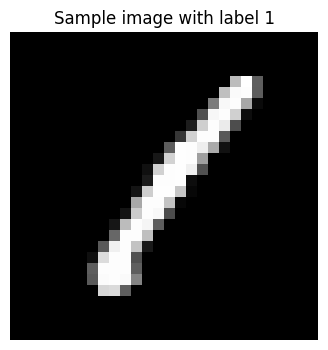

In [ ]:
# Display the same image

plt.figure(figsize=(4, 4))
plt.imshow(sample_image, cmap="gray")
plt.title(f"Sample image with label {sample_label}")
plt.axis("off")
plt.show()

## Step 7: Normalize the pixel values

Pixel values range from 0 to 255.

To help many machine learning models work better, we often scale pixel values to the range **0 to 1** by dividing by 255.

In [ ]:
# Step 7: Normalize the features

X = X / 255.0

X.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---

## ⚙️ Step 7: Normalizing the Pixel Values

In this step, we scale the pixel values so that they fall within a smaller and more consistent range.

---

## 🔹 Why Do We Need This?

Earlier, we saw that:

* Pixel values range from **0 to 255**

This means:

* Some values are very large compared to others
* Machine learning models can struggle when input values are on large or inconsistent scales

👉 To fix this, we **normalize** the data.

---

## 🔹 What is Normalization?

Normalization is the process of scaling values to a standard range.

In this case:

* We convert pixel values from **0–255 → 0–1**

---

## 🔹 Code Explanation

`X = X / 255.0`

* Divides every pixel value in the dataset by **255**
* This scales all values into the range **0 to 1**

Example:

* `0 → 0.0`
* `255 → 1.0`
* `128 → 0.50`

---

`X.head()`

* Displays the first few rows of the normalized dataset
* Allows us to verify that the transformation worked

---

## 🔍 Understanding the Output

Before normalization:

* Pixel values looked like:
  `0, 50, 120, 255`

After normalization:

* Pixel values now look like:
  `0.0, 0.19, 0.47, 1.0`

---

## 🧠 What Has Changed?

* The **structure of the data is the same**
* The **relative differences between pixels remain the same**
* Only the **scale of the values has changed**

---

## 🧩 Why This Matters for Machine Learning

Normalization helps because:

* Models learn **faster**
* Models become **more stable**
* It prevents certain features from dominating due to large values

👉 Many algorithms (especially gradient-based models) perform better when inputs are between **0 and 1**

---

## 🧠 Connecting to Earlier Concepts

* **Input (X)**

  * Still the pixel values
  * Now scaled between 0 and 1

* **Output (y)**

  * Remains unchanged
  * Still the correct digit labels

---

## 💡 Key Insight

> We are not changing the meaning of the data — we are only changing its scale to make learning easier for the model.

---

## 🎯 What We Have Achieved

By the end of this step, we:

* scaled all pixel values to a consistent range
* improved the dataset for machine learning
* prepared the input features (X) for model training

---



## Step 8: Split into training and testing data

We train the model on one part of the data and test it on another part.

This helps us see whether the model can generalize to new images it has not seen before.

In [18]:
# Step 8: Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (33600, 784)
X_test : (8400, 784)
y_train: (33600,)
y_test : (8400,)


## Step 9: Train a simple image classification model

For this beginner notebook, we will use **Logistic Regression**.

Why this model?

- it is simple
- it trains quickly
- it helps students focus on the computer vision idea without needing deep learning yet

Later, students can compare this with:
- KNN
- Decision Trees
- Random Forest
- Neural Networks

In [20]:
# Step 9: Train the model

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


## Step 10: Make predictions

Now the model will try to predict the labels of images it has not seen before.

In [21]:
# Step 10: Predict on the test set

y_pred = model.predict(X_test)

print("Predictions made successfully.")
print("First 20 predictions:", y_pred[:20])

Predictions made successfully.
First 20 predictions: [1 8 6 8 5 7 6 7 7 7 8 8 4 4 7 6 7 1 1 4]


## Step 11: Evaluate the model

We will start with **accuracy**.

Accuracy tells us the proportion of test images the model classified correctly.

In [22]:
# Step 11a: Accuracy

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9137


In [23]:
# Step 11b: Detailed classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       827
           1       0.93      0.98      0.95       937
           2       0.91      0.90      0.91       835
           3       0.90      0.88      0.89       870
           4       0.92      0.90      0.91       814
           5       0.87      0.86      0.86       759
           6       0.95      0.96      0.96       827
           7       0.93      0.93      0.93       880
           8       0.88      0.85      0.87       813
           9       0.88      0.90      0.89       838

    accuracy                           0.91      8400
   macro avg       0.91      0.91      0.91      8400
weighted avg       0.91      0.91      0.91      8400



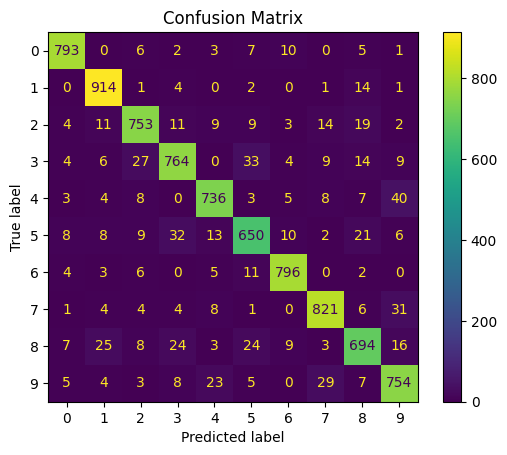

In [24]:
# Step 11c: Confusion matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Step 12: Show predictions visually

This is the fun part.

We will display some test images together with:

- the true label
- the predicted label

This helps students see the model come to life.

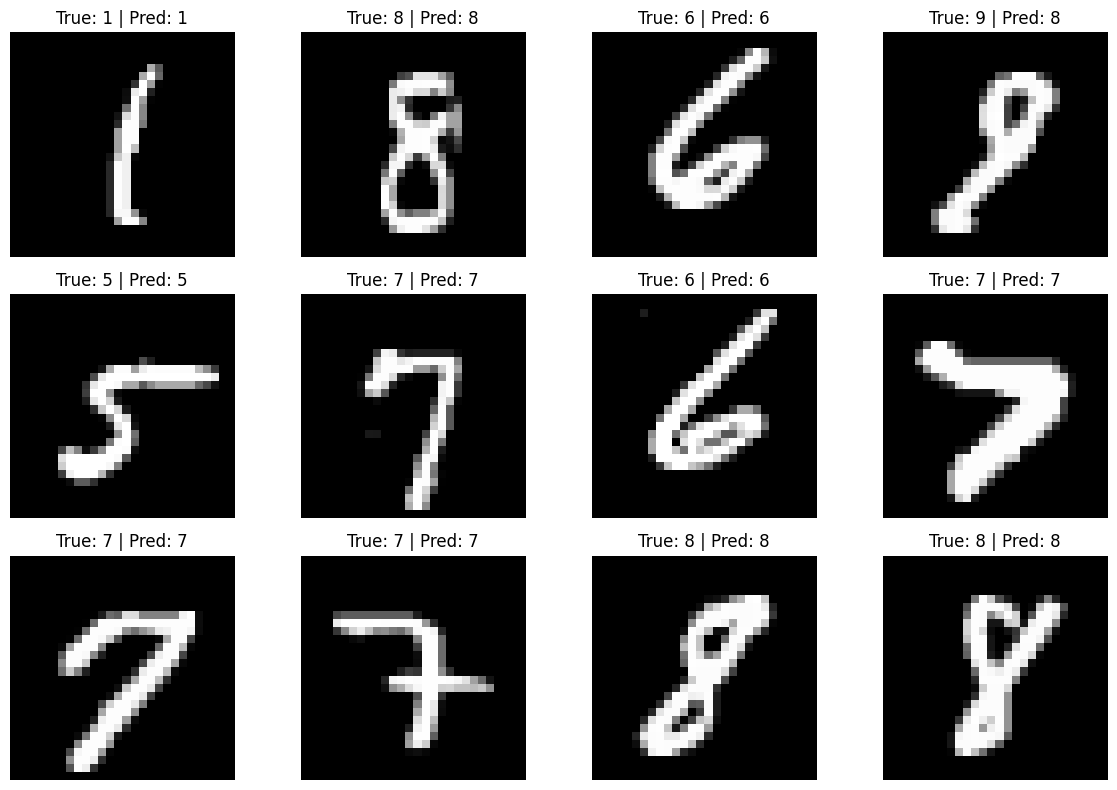

In [25]:
# Step 12: Visualize predictions

X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

plt.figure(figsize=(12, 8))

for i in range(12):
    image = X_test_reset.iloc[i].values.reshape(28, 28)
    true_label = y_test_reset.iloc[i]
    predicted_label = y_pred[i]

    plt.subplot(3, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"True: {true_label} | Pred: {predicted_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 13: Find mistakes the model made

Even good models make mistakes.

Let us display some incorrectly classified images.

In [26]:
# Step 13: Show some incorrect predictions

incorrect_indices = np.where(y_test_reset.values != y_pred)[0]

print("Number of incorrect predictions:", len(incorrect_indices))
print("First 10 incorrect indices:", incorrect_indices[:10])

Number of incorrect predictions: 725
First 10 incorrect indices: [  3  14  25  36  65  85  89  92 118 119]


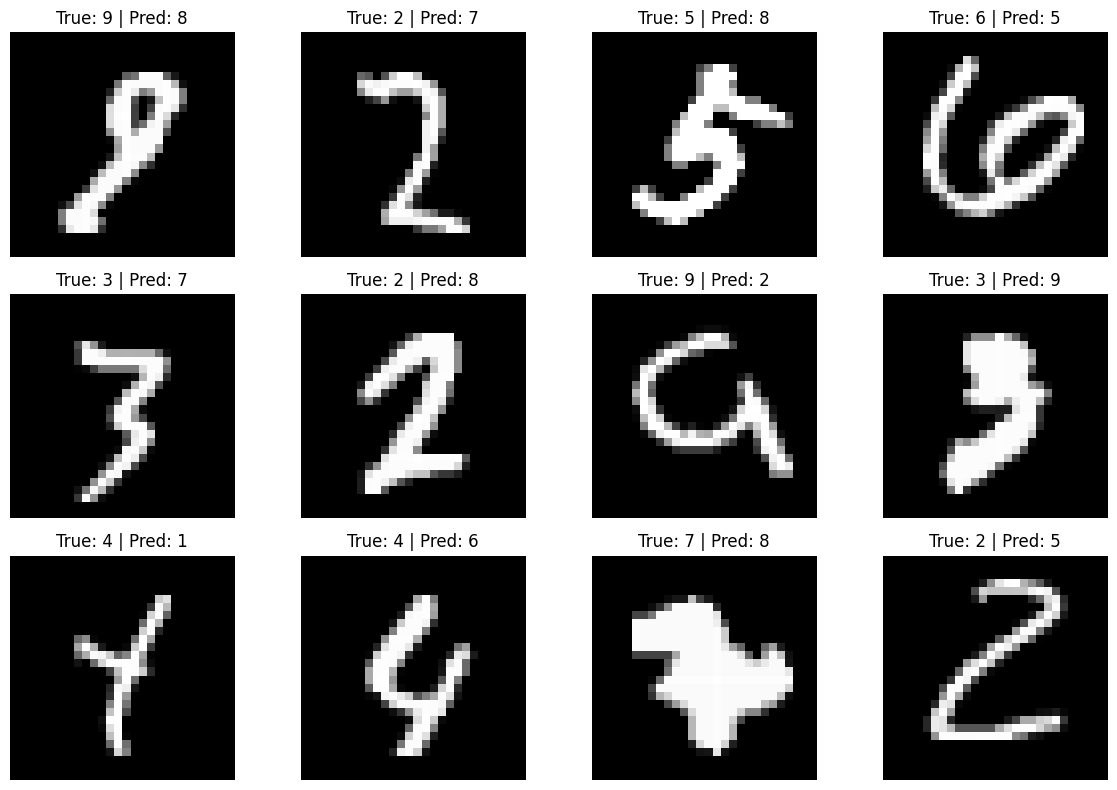

In [27]:
# Visualize some mistakes

plt.figure(figsize=(12, 8))

for plot_idx, wrong_idx in enumerate(incorrect_indices[:12]):
    image = X_test_reset.iloc[wrong_idx].values.reshape(28, 28)
    true_label = y_test_reset.iloc[wrong_idx]
    predicted_label = y_pred[wrong_idx]

    plt.subplot(3, 4, plot_idx + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"True: {true_label} | Pred: {predicted_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Interpretation and discussion

A few important teaching points:

1. The model is learning from **pixel patterns**, not from human-style understanding.
2. Some digits are easier to classify than others.
3. Messy handwriting can confuse the model.
4. This is a simple baseline model, not a deep learning model.
5. Even with a simple model, we can already see real computer vision happening.

---

## Beginner reflection questions

Use these in class discussion:

- Why do we say images are data?
- Why did we reshape the row into 28 × 28?
- Why do we normalize pixel values?
- Why do we split into train and test data?
- What does the confusion matrix help us understand?
- Why might the model confuse some digits?

## Optional extension activities

If you want to extend the live coding session, try one or more of these:

### Extension 1: Train a KNN model
Compare Logistic Regression with K-Nearest Neighbors.

### Extension 2: Train a Random Forest model
See how another model performs on the same image data.

### Extension 3: Predict a single image manually
Take one row, reshape it, display it, and ask students to guess the digit before the model predicts.

### Extension 4: Move toward deep learning
Later, you can introduce:
- neural networks
- convolutional neural networks
- TensorFlow or PyTorch

### Extension 5: Relate this to real-world computer vision
Discuss how the same idea scales to:
- face recognition
- medical diagnosis from scans
- traffic sign recognition
- quality control in manufacturing

In [28]:
# Optional Extension 1: Try KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)
print(f"KNN Accuracy: {knn_accuracy:.4f}")

KNN Accuracy: 0.9667


## Final takeaway

Computer vision starts with a simple but powerful idea:

> an image can be represented as numbers, and machine learning can learn patterns from those numbers.

Today, we used a beginner-friendly Kaggle dataset to move from:
- image data
- to pixels
- to model training
- to prediction
- to evaluation

That is the foundation of computer vision.